In [23]:
import pandas as pd

log_returns = pd.read_csv('old/log_returns.csv')

In [5]:
import os
import time
import requests
import pandas as pd
from datetime import datetime, timezone, timedelta
from dateutil.relativedelta import relativedelta
from collections import deque
from threading import Lock
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# ─── CONFIG ──────────────────────────────────────────────────────────────
API_KEY      = "${CMC_API_KEY}"
CMC_BASE     = "https://pro-api.coinmarketcap.com"
OUTPUT_DIR   = "./cmc_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── RATE LIMITER ─────────────────────────────────────────────────────────
CALL_TIMES = deque()
RL_LOCK    = Lock()
MAX_CALLS  = 30
PERIOD     = 61  # seconds

def rate_limit():
    with RL_LOCK:
        now = time.time()
        # drop old timestamps
        while CALL_TIMES and CALL_TIMES[0] <= now - PERIOD:
            CALL_TIMES.popleft()
        if len(CALL_TIMES) >= MAX_CALLS:
            wait = CALL_TIMES[0] + PERIOD - now
            time.sleep(wait)
            now = time.time()
            while CALL_TIMES and CALL_TIMES[0] <= now - PERIOD:
                CALL_TIMES.popleft()
        CALL_TIMES.append(now)

# ─── TIME WINDOW ─────────────────────────────────────────────────────────
END_DT      = datetime.now(timezone.utc)
START_DT    = END_DT - relativedelta(months=24)
MAX_WINDOW  = timedelta(days=30)

# ─── HTTP SESSION & RETRIES ───────────────────────────────────────────────
session = requests.Session()
retry = Retry(
    total=5,
    status_forcelist=[500, 502, 503, 504],
    backoff_factor=1,
    respect_retry_after_header=True
)
adapter = HTTPAdapter(max_retries=retry)
session.mount("https://", adapter)
session.mount("http://", adapter)
session.headers.update({
    "Accepts":           "application/json",
    "X-CMC_PRO_API_KEY": API_KEY
})

def cmc_get(path, params):
    """
    Robust GET:
      - rate-limits to MAX_CALLS / PERIOD
      - handles HTTP 429 with backoff
      - retries on ConnectionError/Timeout until Wi-Fi returns
    """
    url = CMC_BASE + path
    backoff = 1
    while True:
        rate_limit()
        try:
            resp = session.get(url, params=params, timeout=10)
        except (requests.exceptions.ConnectionError,
                requests.exceptions.Timeout) as net_err:
            print(f"[NETWORK ERROR] {net_err}; retrying in 10s…")
            time.sleep(10)
            continue

        if resp.status_code == 429:
            retry_after = resp.headers.get("Retry-After")
            wait = int(retry_after) if retry_after else backoff
            print(f"[429] rate-limit, sleeping for {wait}s")
            time.sleep(wait)
            backoff = min(backoff * 2, 60)
            continue

        if resp.status_code != 200:
            print(f"[ERROR {resp.status_code}] {url}")
            print("Params:", params)
            print("Body:", resp.text)
        resp.raise_for_status()
        return resp.json()

# ─── 1) Fetch ETH’s ID and summary ────────────────────────────────────────
eth_info = cmc_get("/v1/cryptocurrency/quotes/latest", {
    "symbol":  "ETH",
    "convert": "USD"
})
ETH_ID  = eth_info["data"]["ETH"]["id"]
eth_summary = {
    "symbol":             eth_info["data"]["ETH"]["symbol"],
    "circulating_supply": eth_info["data"]["ETH"].get("circulating_supply"),
    "price_usd":          eth_info["data"]["ETH"]["quote"]["USD"]["price"],
    "market_cap_usd":     eth_info["data"]["ETH"]["quote"]["USD"]["market_cap"]
}
# write summary
pd.DataFrame([eth_summary]).set_index("symbol") \
  .to_csv(os.path.join(OUTPUT_DIR, "eth_summary.csv"))
print(f"→ Written eth_summary.csv")

# ─── 2) Fetch ETH historical OHLCV in 30-day slices ───────────────────────
slices = []
ws = START_DT
print("Fetching ETH 24-month history…")
while ws < END_DT:
    we = min(ws + MAX_WINDOW, END_DT)
    params = {
        "id":         ETH_ID,
        "time_start": ws.strftime("%Y-%m-%d"),
        "time_end":   we.strftime("%Y-%m-%d"),
        "interval":   "daily",
        "convert":    "USD"
    }
    try:
        payload = cmc_get("/v1/cryptocurrency/ohlcv/historical", params)
        quotes  = payload.get("data", {}).get("quotes", [])
    except requests.HTTPError as e:
        code = e.response.status_code if e.response is not None else "N/A"
        print(f" → Skipping slice {ws.date()}–{we.date()} (HTTP {code})")
        ws = we
        continue

    if quotes:
        df = pd.DataFrame([{
            "date":   q["time_open"][:10],
            "close":  q["quote"]["USD"]["close"],
            "volume": q["quote"]["USD"]["volume"]
        } for q in quotes]).set_index("date")
        slices.append(df)

    ws = we

if not slices:
    raise RuntimeError("No OHLCV data returned for ETH in the 24-month window.")

# ─── 3) Concatenate, clean, and save historical CSV ───────────────────────
eth_hist = pd.concat(slices).drop_duplicates().sort_index()
eth_hist.index = pd.to_datetime(eth_hist.index)
eth_hist.to_csv(os.path.join(OUTPUT_DIR, "eth_ohlcv.csv"))
print(f"→ Written eth_ohlcv.csv")

→ Written eth_summary.csv
Fetching ETH 24-month history…
[429] rate-limit, sleeping for 1s
[429] rate-limit, sleeping for 2s
[429] rate-limit, sleeping for 4s
[429] rate-limit, sleeping for 8s
[429] rate-limit, sleeping for 16s
[429] rate-limit, sleeping for 32s
→ Written eth_ohlcv.csv


In [24]:
eth_data = pd.read_csv('old/eth_ohlcv.csv')

In [25]:
eth_data = eth_data.set_index(eth_data.columns[0])
eth_data.index.rename('Date', inplace=True)
eth_data.head()

,close,volume
Date,,
2023-05-30,1901.026568,5.363440e+09
2023-05-31,1874.130435,5.984513e+09
2023-06-01,1862.201451,5.640027e+09
2023-06-02,1907.256636,6.097746e+09
2023-06-03,1892.412529,3.472275e+09


In [26]:
close_names = []
vol_names = []
col_names = eth_data.columns.tolist()
for name in col_names:
    if "close" in name:
        close_names.append(name)
    else: 
        vol_names.append(name)

In [27]:
data_prices = eth_data[close_names]
vol_names = eth_data[vol_names]
data_prices.head()

,close
Date,
2023-05-30,1901.026568
2023-05-31,1874.130435
2023-06-01,1862.201451
2023-06-02,1907.256636
2023-06-03,1892.412529


In [28]:
vol_names.head()

,volume
Date,
2023-05-30,5.363440e+09
2023-05-31,5.984513e+09
2023-06-01,5.640027e+09
2023-06-02,6.097746e+09
2023-06-03,3.472275e+09


In [29]:
import numpy as np
returns = pd.DataFrame()
returns['ETH_returns'] = np.log(data_prices['close'] / data_prices['close'].shift(1))

In [30]:
returns.head()

,ETH_returns
Date,
2023-05-30,NaN
2023-05-31,-0.014249
2023-06-01,-0.006385
2023-06-02,0.023907
2023-06-03,-0.007813


In [31]:
eth_log_returns = returns.iloc[1:]
eth_log_returns.head()

,ETH_returns
Date,
2023-05-31,-0.014249
2023-06-01,-0.006385
2023-06-02,0.023907
2023-06-03,-0.007813
2023-06-04,-0.001004


In [32]:
eth_log_returns.tail()

,ETH_returns
Date,
2025-05-24,0.001663
2025-05-25,0.008310
2025-05-26,0.004838
2025-05-27,0.037857
2025-05-28,0.007163


In [39]:
log_returns = log_returns.set_index(log_returns.columns[0])
log_returns.head()

,DASH_returns,BabyDoge_returns,SNX_returns,GLM_returns,SFP_returns,TFUEL_returns,BLUR_returns,ROSE_returns,ZIL_returns,CKB_returns,...,SCRT_returns,CTSI_returns,OXT_returns,EDU_returns,C98_returns,ACT_returns,OAS_returns,FUN_returns,RIF_returns,WIN_returns
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-17,0.026086,-0.000396,0.116358,0.015840,0.015194,0.012827,0.032185,0.007219,0.029219,0.020415,...,0.006629,0.191383,0.006544,0.064975,0.029541,0.011127,-0.000292,-0.003611,0.016289,0.008294
2023-05-18,-0.026139,-0.017877,-0.000817,-0.015614,-0.015810,-0.003601,-0.035692,-0.019886,-0.039257,-0.017996,...,0.004906,-0.078314,-0.021916,-0.084784,-0.019588,0.038775,-0.013787,-0.004070,-0.019091,-0.025690
2023-05-19,0.030268,-0.008392,-0.006596,-0.000475,0.010314,-0.002156,0.019281,-0.009962,0.015491,0.003434,...,-0.016899,-0.004519,0.004957,0.001925,0.021626,0.196746,0.003438,0.003296,-0.004244,0.000655
2023-05-20,-0.004435,0.013423,-0.001361,0.001608,0.012908,-0.005186,0.003417,0.004713,-0.004940,0.004130,...,-0.016825,-0.019823,0.003241,0.000033,-0.001718,0.135605,-0.019042,0.074735,0.026687,0.003034
2023-05-21,-0.008911,-0.024482,-0.028067,-0.019833,-0.025045,-0.034550,-0.031973,-0.028531,-0.030096,-0.028915,...,-0.020203,-0.032206,-0.020200,-0.016463,-0.037080,-0.036914,0.001249,-0.005572,-0.032921,-0.002103


In [43]:
log_returns.tail()

,DASH_returns,BabyDoge_returns,SNX_returns,GLM_returns,SFP_returns,TFUEL_returns,BLUR_returns,ROSE_returns,ZIL_returns,CKB_returns,...,SCRT_returns,CTSI_returns,OXT_returns,EDU_returns,C98_returns,ACT_returns,OAS_returns,FUN_returns,RIF_returns,WIN_returns
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-10,0.051306,0.099119,0.119800,0.037324,0.046167,0.035630,0.078975,0.153534,0.053812,0.078331,...,0.105028,0.064346,0.035485,0.090624,0.117251,0.001759,0.051126,-0.012925,0.081005,0.053072
2025-05-11,-0.025809,-0.031051,-0.052824,-0.030566,-0.034896,-0.026415,-0.062944,-0.049519,-0.016542,-0.007161,...,-0.023753,-0.002684,-0.045842,-0.021894,-0.029597,0.132750,-0.029946,0.051346,-0.034364,0.038317
2025-05-12,0.011285,-0.004405,0.015056,0.012469,0.015580,-0.002364,0.039748,0.087503,-0.012670,0.050449,...,0.025367,0.008999,0.024685,0.081233,-0.018219,-0.076267,0.001586,0.088598,0.047894,-0.020293
2025-05-13,0.035335,0.141763,0.055415,0.019162,0.017334,0.019387,0.027824,0.013328,0.034938,-0.001025,...,-0.012828,0.040060,0.013705,-0.017053,0.063773,-0.045132,-0.011401,0.058852,0.040049,0.019751
2025-05-14,-0.036168,-0.081441,-0.049606,-0.030026,-0.032876,-0.031111,-0.061845,-0.057877,-0.054402,-0.053303,...,-0.057245,-0.045128,-0.047727,-0.083049,-0.055719,-0.010420,-0.003721,-0.027287,0.022446,0.002145


In [40]:
common_idx = log_returns.index.intersection(eth_log_returns.index)

log_returns_shared     = log_returns.loc[common_idx]
eth_log_returns_shared = eth_log_returns.loc[common_idx]

In [41]:
log_returns_shared.head()

,DASH_returns,BabyDoge_returns,SNX_returns,GLM_returns,SFP_returns,TFUEL_returns,BLUR_returns,ROSE_returns,ZIL_returns,CKB_returns,...,SCRT_returns,CTSI_returns,OXT_returns,EDU_returns,C98_returns,ACT_returns,OAS_returns,FUN_returns,RIF_returns,WIN_returns
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-31,-0.046592,-0.021767,-0.032977,-0.019603,-0.001417,-0.028345,-0.046443,-0.033941,-0.035221,-0.024246,...,-0.109061,-0.045055,-0.027713,0.012328,-0.048733,0.251616,-0.017346,-0.013002,-0.027972,-0.029349
2023-06-01,0.000173,-0.037707,-0.000262,-0.009906,-0.010017,0.006738,-0.005172,0.012810,-0.007929,-0.008837,...,-0.011172,-0.009426,-0.005295,-0.039813,0.007516,0.039505,-0.029615,0.004061,0.017031,0.004611
2023-06-02,0.020182,-0.010424,0.023523,0.013575,-0.002777,0.014468,0.052877,0.022531,0.031211,0.037677,...,0.008023,0.021643,0.019338,0.020138,0.036354,-0.389652,0.131175,0.009058,-0.003388,0.039466
2023-06-03,-0.002252,-0.008754,-0.011759,0.003568,0.005055,-0.002995,0.020075,0.011323,0.008670,-0.007291,...,0.013458,-0.015206,-0.008102,-0.022235,0.000080,0.049882,-0.002494,-0.011105,-0.014540,0.026154
2023-06-04,0.000101,-0.018066,0.001833,0.003354,-0.002562,0.010451,-0.021214,0.043427,0.017414,0.001877,...,-0.026127,0.004882,0.003282,-0.002495,0.008126,0.054101,0.049903,-0.000226,-0.012915,-0.023438


In [42]:
log_returns_shared.tail()

,DASH_returns,BabyDoge_returns,SNX_returns,GLM_returns,SFP_returns,TFUEL_returns,BLUR_returns,ROSE_returns,ZIL_returns,CKB_returns,...,SCRT_returns,CTSI_returns,OXT_returns,EDU_returns,C98_returns,ACT_returns,OAS_returns,FUN_returns,RIF_returns,WIN_returns
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-10,0.051306,0.099119,0.119800,0.037324,0.046167,0.035630,0.078975,0.153534,0.053812,0.078331,...,0.105028,0.064346,0.035485,0.090624,0.117251,0.001759,0.051126,-0.012925,0.081005,0.053072
2025-05-11,-0.025809,-0.031051,-0.052824,-0.030566,-0.034896,-0.026415,-0.062944,-0.049519,-0.016542,-0.007161,...,-0.023753,-0.002684,-0.045842,-0.021894,-0.029597,0.132750,-0.029946,0.051346,-0.034364,0.038317
2025-05-12,0.011285,-0.004405,0.015056,0.012469,0.015580,-0.002364,0.039748,0.087503,-0.012670,0.050449,...,0.025367,0.008999,0.024685,0.081233,-0.018219,-0.076267,0.001586,0.088598,0.047894,-0.020293
2025-05-13,0.035335,0.141763,0.055415,0.019162,0.017334,0.019387,0.027824,0.013328,0.034938,-0.001025,...,-0.012828,0.040060,0.013705,-0.017053,0.063773,-0.045132,-0.011401,0.058852,0.040049,0.019751
2025-05-14,-0.036168,-0.081441,-0.049606,-0.030026,-0.032876,-0.031111,-0.061845,-0.057877,-0.054402,-0.053303,...,-0.057245,-0.045128,-0.047727,-0.083049,-0.055719,-0.010420,-0.003721,-0.027287,0.022446,0.002145


In [44]:
eth_log_returns_shared.head()

,ETH_returns
Date,
2023-05-31,-0.014249
2023-06-01,-0.006385
2023-06-02,0.023907
2023-06-03,-0.007813
2023-06-04,-0.001004


In [ ]:
excess_log_returns = log_returns_shared.subtract(
    eth_log_returns_shared["ETH_returns"], 
    axis=0
)

In [46]:
excess_log_returns.head()

,DASH_returns,BabyDoge_returns,SNX_returns,GLM_returns,SFP_returns,TFUEL_returns,BLUR_returns,ROSE_returns,ZIL_returns,CKB_returns,...,SCRT_returns,CTSI_returns,OXT_returns,EDU_returns,C98_returns,ACT_returns,OAS_returns,FUN_returns,RIF_returns,WIN_returns
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-31,-0.032343,-0.007518,-0.018728,-0.005354,0.012832,-0.014096,-0.032193,-0.019692,-0.020972,-0.009996,...,-0.094811,-0.030805,-0.013464,0.026578,-0.034484,0.265866,-0.003097,0.001247,-0.013722,-0.015100
2023-06-01,0.006558,-0.031321,0.006124,-0.003521,-0.003632,0.013123,0.001213,0.019195,-0.001544,-0.002452,...,-0.004786,-0.003041,0.001091,-0.033427,0.013901,0.045891,-0.023229,0.010446,0.023416,0.010997
2023-06-02,-0.003725,-0.034331,-0.000383,-0.010331,-0.026683,-0.009439,0.028971,-0.001375,0.007305,0.013770,...,-0.015883,-0.002264,-0.004568,-0.003769,0.012448,-0.413558,0.107269,-0.014848,-0.027294,0.015559
2023-06-03,0.005561,-0.000940,-0.003946,0.011381,0.012868,0.004818,0.027889,0.019136,0.016483,0.000522,...,0.021272,-0.007393,-0.000288,-0.014422,0.007893,0.057696,0.005320,-0.003291,-0.006727,0.033967
2023-06-04,0.001105,-0.017062,0.002837,0.004357,-0.001558,0.011455,-0.020210,0.044431,0.018418,0.002881,...,-0.025123,0.005886,0.004286,-0.001491,0.009129,0.055105,0.050907,0.000778,-0.011912,-0.022434


In [47]:
corr = excess_log_returns.corr()

In [48]:
print(corr.isna().sum().sum())

0


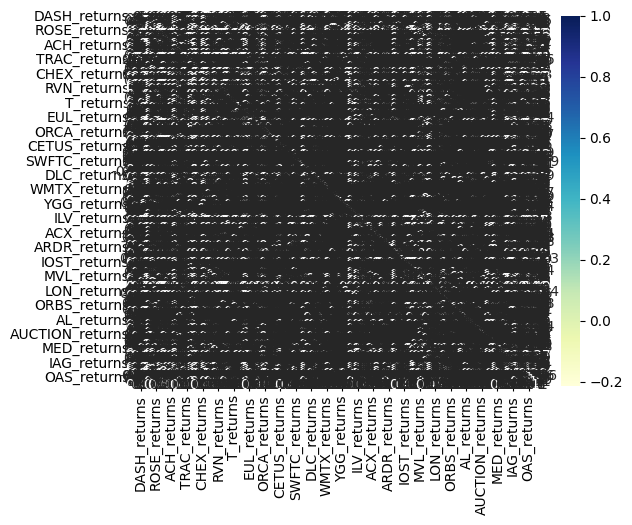

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, cmap="YlGnBu", annot=True)

plt.show()

In [52]:
excess_log_returns.to_csv('excess_log_returns.csv')
excess_log_returns.shape

(715, 179)

In [51]:
corr_long = (
    corr
    .stack()
    .reset_index(name="Correlation")
    .rename(columns={"level_0":"Asset1","level_1":"Asset2"})
)

corr_long.to_csv("corr_full.csv", index=False)

In [ ]:
import os
import requests
import time
import pandas as pd

GRAPH_API_KEY = os.getenv("GRAPH_API_KEY", "964754b574f6c5732ca164b97729829a")

DEXS = [
    {
        "name":        "SushiSwap V2",
        "subgraph_id": "8yBXBTMfdhsoE5QCf7KnoPmQb7QAWtRzESfYjiCjGEM9",
        "candidates": [
            {"entity": "pairs",         "liq_field": "reserveUSD"},
        ]
    },
    {
        "name":        "Uniswap V2",
        "subgraph_id": "CStW6CSQbHoXsgKuVCrk3uShGA4JX3CAzzv2x9zaGf8w",
        "candidates": [
            {"entity": "pairs",         "liq_field": "reserveUSD"},
        ]
    },
    {
        "name":        "PancakeSwap V2",
        "subgraph_id": "EsL7geTRcA3LaLLM9EcMFzYbUgnvf8RixoEEGErrodB3",
        "candidates": [
            {"entity": "pairs",         "liq_field": "reserveUSD"},
        ]
    },
    {
        "name":        "PancakeSwap V3",
        "subgraph_id": "251MHFNN1rwjErXD2efWMpNS73SANZN8Ua192zw6iXve",
        "candidates": [
            {"entity": "pools",         "liq_field": "totalValueLockedUSD"},
            {"entity": "poolDayDatas",  "liq_field": "liquidity"},
        ]
    },
]

HEADERS = {"Content-Type": "application/json"}

QUERY_TEMPLATE = """
query($min: BigDecimal!, $max: BigDecimal!, $first: Int!, $skip: Int!) {{
  {entity}(
    first: $first,
    skip:  $skip,
    where: {{
      {liq}_gt: $min,
      {liq}_lt: $max
    }},
    orderBy: {liq},
    orderDirection: desc
  ) {{
    id
    {liq}
    token0 {{ id symbol }}
    token1 {{ id symbol }}
  }}
}}
"""

def detect_and_fetch(subgraph, min_usd=1e5, max_usd=1e6, batch=100):
    url = f"https://gateway.thegraph.com/api/{GRAPH_API_KEY}/subgraphs/id/{subgraph['subgraph_id']}"
    for cand in subgraph["candidates"]:
        query = QUERY_TEMPLATE.format(entity=cand["entity"], liq=cand["liq_field"])
        skip = 0
        records = []
        try:
            while True:
                resp = requests.post(
                    url,
                    json={
                        "query": query,
                        "variables": {
                            "min":   min_usd,
                            "max":   max_usd,
                            "first": batch,
                            "skip":  skip
                        }
                    },
                    headers=HEADERS
                )
                resp.raise_for_status()
                data = resp.json()
                if data.get("errors"):
                    raise RuntimeError(data["errors"])
                pool_list = data["data"].get(cand["entity"], [])
                if not pool_list:
                    break
                for p in pool_list:
                    records.append({
                        "pool_id":        p["id"],
                        "liquidity":      float(p[cand["liq_field"]]),
                        "token0_symbol":  p["token0"]["symbol"],
                        "token0_address": p["token0"]["id"].lower(),
                        "token1_symbol":  p["token1"]["symbol"],
                        "token1_address": p["token1"]["id"].lower(),
                    })
                skip += len(pool_list)
                time.sleep(0.2)
            print(f"  • Using `{cand['entity']}` ➔ found {len(records)} pools\n")
            return records
        except RuntimeError as e:
            print(f"  [!] `{cand['entity']}` failed: {e}\n")
    print(f"  × No working entity for {subgraph['name']}\n")
    return []

def filter_usd_eth(df: pd.DataFrame) -> pd.DataFrame:
    """Remove any rows where either token symbol contains 'usd' or 'eth'."""
    mask = ~(
        df["token0_symbol"].str.contains("usd|eth", case=False) |
        df["token1_symbol"].str.contains("usd|eth", case=False)
    )
    return df[mask]

all_results = {}
for dex in DEXS:
    print(f"→ {dex['name']}:")
    recs = detect_and_fetch(dex)
    if recs:
        df = pd.DataFrame(recs)
        df = filter_usd_eth(df).sort_values("liquidity", ascending=False).reset_index(drop=True)
        print(df.to_string(index=False))
    all_results[dex["name"]] = recs
    print()

# Combine tokens across all DEXs, then filter out USD/ETH symbols
combined_tokens = set()
for recs in all_results.values():
    for r in recs:
        combined_tokens.add((r["token0_address"], r["token0_symbol"]))
        combined_tokens.add((r["token1_address"], r["token1_symbol"]))

# Filter out USD/ETH
filtered = [
    (addr, sym) for addr, sym in combined_tokens
    if not ("usd" in sym.lower() or "eth" in sym.lower())
]

print(f"Total unique low-liquidity tokens (excl. USD/ETH): {len(filtered)}")
for addr, sym in sorted(filtered, key=lambda x: x[1]):
    print(f"{sym} at {addr}")
